
# Compulsory Assignment #2 — Course-aligned solution
**Machine Learning and Deep Learning (CDSCO2041C)**

**Student IDs:** `ADD STUDENT IDs HERE`

## Aim
This notebook solves the assignment using only methods that are explicitly within the scope of the course lectures and follows the course workflow:

**Data collection → preprocessing/cleaning → EDA → model building → evaluation → interpretation**

That workflow is stated in the lecture slides, together with the requirement to analyze a realistic dataset using covered models and to justify methodological choices. The notebook therefore emphasizes:
- preprocessing and feature construction,
- EDA in the same order suggested in the lectures,
- train/validation/test discipline,
- cross-validation,
- regularization to reduce overfitting,
- interpretable rules and transparent conclusions.

## Assignment questions
Using the provided Ethereum (ETH/DKK) and Novo Nordisk datasets and using **RoI** as the primary metric, answer:

1. Should you invest in Ethereum or Novo Nordisk?
2. How should DKK 250,000 be allocated?
3. Are there seasonal patterns or timing effects?

## Course-methodology mapping
The choices below are directly aligned with the lecture content:

- **Lecture 02:** preprocessing, EDA, scaling, train/validation/test split, cross-validation, regression/classification metrics, bias-variance tradeoff.
- **Lecture 03:** unsupervised learning, clustering, Gaussian Mixture Models (GMM) and their probabilistic interpretation.
- **Lecture 04:** linear/logistic models, regularization, Elastic Net, interpretable supervised baselines.
- **Lecture 05:** decision trees for interpretable investment rules.
- **Later anomaly-detection lecture material in the merged slide deck:** Isolation Forest for extreme events.

Because the data are chronological financial series, evaluation is done with **time-aware splits** rather than random shuffling to avoid look-ahead leakage.


In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LogisticRegression, ElasticNet
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 1. Load and clean the data

In [2]:

def parse_suffix(x):
    s = str(x).strip().replace(",", "")
    if s in {"", "nan", "None"}:
        return np.nan
    mult = 1
    if s.endswith("K"):
        mult = 1e3
        s = s[:-1]
    elif s.endswith("M"):
        mult = 1e6
        s = s[:-1]
    elif s.endswith("B"):
        mult = 1e9
        s = s[:-1]
    elif s.endswith("T"):
        mult = 1e12
        s = s[:-1]
    return pd.to_numeric(s, errors="coerce") * mult

def clean_novo_num(s):
    return pd.to_numeric(
        s.astype(str)
         .str.replace(",", "", regex=False)
         .str.replace(r"^\.", "", regex=True),
        errors="coerce"
    )

def load_eth(path="/mnt/data/_eth_dkk.csv"):
    df = pd.read_csv(path, sep=";")
    df.columns = ["Date", "Open", "High", "Low", "Close", "Volume", "MarketCap", "PctChange"]
    df["Date"] = pd.to_datetime(df["Date"])
    for col in ["Open", "High", "Low", "Close", "PctChange"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    for col in ["Volume", "MarketCap"]:
        df[col] = df[col].apply(parse_suffix)
    return df.sort_values("Date").reset_index(drop=True)

def load_novo(path="/mnt/data/_XCSE_NOVO-1.csv"):
    df = pd.read_csv(path)
    df["Date"] = pd.to_datetime(df["Date"])
    for col in ["Open", "High", "Low", "Close"]:
        df[col] = clean_novo_num(df[col])
    df["Volume"] = pd.to_numeric(df["Volume"].astype(str).str.replace(",", "", regex=False), errors="coerce")
    return df.sort_values("Date").reset_index(drop=True)

eth_raw = load_eth()
novo_raw = load_novo()

print("Ethereum")
display(eth_raw.head())
print(eth_raw.info())

print("\nNovo Nordisk")
display(novo_raw.head())
print(novo_raw.info())


Ethereum


,Date,Open,High,Low,Close,Volume,MarketCap,PctChange
0,2025-03-01,"16,081.1100","16,394.1000","15,399.3700","15,935.9400","132,890,000,000.0000","1,920,000,000,000.0000",-0.9900
1,2025-03-02,"15,936.0100","18,330.5100","15,610.0200","18,097.1500","111,540,000,000.0000","2,180,000,000,000.0002",13.5600
2,2025-03-03,"17,932.0400","17,970.7800","14,939.6400","15,303.5300","294,590,000,000.0000","1,850,000,000,000.0000",-15.4400
3,2025-03-04,"15,122.4400","15,635.1500","14,025.9500","15,280.7000","244,050,000,000.0000","1,840,000,000,000.0000",-0.1500
4,2025-03-05,"15,010.0600","15,715.1800","14,896.2100","15,494.5400","185,410,000,000.0000","1,870,000,000,000.0000",1.4000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       366 non-null    datetime64[ns]
 1   Open       366 non-null    float64       
 2   High       366 non-null    float64       
 3   Low        366 non-null    float64       
 4   Close      366 non-null    float64       
 5   Volume     366 non-null    float64       
 6   MarketCap  366 non-null    float64       
 7   PctChange  366 non-null    float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 23.0 KB
None

Novo Nordisk


,Date,Open,High,Low,Close,Volume
0,2025-02-27,630.0000,645.8000,628.3000,641.8000,2974061
1,2025-02-28,641.0000,648.2000,631.2000,644.5000,7285161
2,2025-03-03,650.0000,651.2000,636.2000,639.1000,2242871
3,2025-03-04,634.6000,642.4000,616.2000,616.2000,3058878
4,2025-03-05,616.1000,649.4000,614.0000,631.5000,3515981


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    250 non-null    datetime64[ns]
 1   Open    250 non-null    float64       
 2   High    250 non-null    float64       
 3   Low     250 non-null    float64       
 4   Close   250 non-null    float64       
 5   Volume  250 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 11.8 KB
None



**Comment.**  
This follows the preprocessing guidance from the lectures: inspect data structure, fix data types, and convert fields into numeric form before modelling.


## 2. Feature engineering

In [3]:

def add_features(df):
    out = df.copy().sort_values("Date").reset_index(drop=True)
    out["ret_1d"] = out["Close"].pct_change()
    out["log_ret"] = np.log(out["Close"]).diff()
    out["range_pct"] = (out["High"] - out["Low"]) / out["Close"]

    out["vol_5"] = out["ret_1d"].rolling(5).std()
    out["vol_21"] = out["ret_1d"].rolling(21).std()

    out["mom_5"] = out["Close"].pct_change(5)
    out["mom_21"] = out["Close"].pct_change(21)

    out["ma_5"] = out["Close"].rolling(5).mean()
    out["ma_21"] = out["Close"].rolling(21).mean()
    out["ma_ratio"] = out["ma_5"] / out["ma_21"] - 1

    out["volume_chg"] = out["Volume"].pct_change()
    out["volume_ma_5"] = out["Volume"].rolling(5).mean()
    out["volume_ma_21"] = out["Volume"].rolling(21).mean()
    out["volume_ratio"] = out["volume_ma_5"] / out["volume_ma_21"] - 1

    out["month"] = out["Date"].dt.month
    out["day_name"] = out["Date"].dt.day_name()
    return out

eth = add_features(eth_raw)
novo = add_features(novo_raw)

display(eth.head(10))
display(novo.head(10))


,Date,Open,High,Low,Close,Volume,MarketCap,PctChange,ret_1d,log_ret,range_pct,vol_5,vol_21,mom_5,mom_21,ma_5,ma_21,ma_ratio,volume_chg,volume_ma_5,volume_ma_21,volume_ratio,month,day_name
0,2025-03-01,"16,081.1100","16,394.1000","15,399.3700","15,935.9400","132,890,000,000.0000","1,920,000,000,000.0000",-0.9900,NaN,NaN,0.0624,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,Saturday
1,2025-03-02,"15,936.0100","18,330.5100","15,610.0200","18,097.1500","111,540,000,000.0000","2,180,000,000,000.0002",13.5600,0.1356,0.1272,0.1503,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.1607,NaN,NaN,NaN,3,Sunday
2,2025-03-03,"17,932.0400","17,970.7800","14,939.6400","15,303.5300","294,590,000,000.0000","1,850,000,000,000.0000",-15.4400,-0.1544,-0.1677,0.1981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.6411,NaN,NaN,NaN,3,Monday
3,2025-03-04,"15,122.4400","15,635.1500","14,025.9500","15,280.7000","244,050,000,000.0000","1,840,000,000,000.0000",-0.1500,-0.0015,-0.0015,0.1053,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.1716,NaN,NaN,NaN,3,Tuesday
4,2025-03-05,"15,010.0600","15,715.1800","14,896.2100","15,494.5400","185,410,000,000.0000","1,870,000,000,000.0000",1.4000,0.0140,0.0139,0.0529,NaN,NaN,NaN,NaN,"16,022.3720",NaN,NaN,-0.2403,"193,696,000,000.0000",NaN,NaN,3,Wednesday
5,2025-03-06,"15,479.5200","16,020.9200","15,032.8000","15,207.5100","126,260,000,000.0000","1,830,000,000,000.0000",-1.8500,-0.0185,-0.0187,0.0650,0.1032,NaN,-0.0457,NaN,"15,876.6860",NaN,NaN,-0.3190,"192,370,000,000.0000",NaN,NaN,3,Thursday
6,2025-03-07,"15,148.7800","15,535.7900","14,458.2100","14,731.8500","139,380,000,000.0000","1,780,000,000,000.0000",-3.1300,-0.0313,-0.0318,0.0731,0.0671,NaN,-0.1860,NaN,"15,203.6260",NaN,NaN,0.1039,"197,938,000,000.0000",NaN,NaN,3,Friday
7,2025-03-08,"14,744.7000","15,387.2700","14,493.1300","15,171.4300","106,410,000,000.0000","1,830,000,000,000.0000",2.9800,0.0298,0.0294,0.0589,0.0245,NaN,-0.0086,NaN,"15,177.2060",NaN,NaN,-0.2365,"160,302,000,000.0000",NaN,NaN,3,Saturday
8,2025-03-09,"15,171.3600","15,229.4000","13,698.6100","13,910.3200","71,020,000,000.0000","1,680,000,000,000.0000",-8.3100,-0.0831,-0.0868,0.1100,0.0440,NaN,-0.0897,NaN,"14,903.1300",NaN,NaN,-0.3326,"125,696,000,000.0000",NaN,NaN,3,Sunday
9,2025-03-10,"13,911.6700","14,820.3500","12,462.8200","12,842.1500","199,620,000,000.0000","1,550,000,000,000.0000",-7.6800,-0.0768,-0.0799,0.1836,0.0462,NaN,-0.1712,NaN,"14,372.6520",NaN,NaN,1.8108,"128,538,000,000.0000",NaN,NaN,3,Monday


,Date,Open,High,Low,Close,Volume,ret_1d,log_ret,range_pct,vol_5,vol_21,mom_5,mom_21,ma_5,ma_21,ma_ratio,volume_chg,volume_ma_5,volume_ma_21,volume_ratio,month,day_name
0,2025-02-27,630.0000,645.8000,628.3000,641.8000,2974061,NaN,NaN,0.0273,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,Thursday
1,2025-02-28,641.0000,648.2000,631.2000,644.5000,7285161,0.0042,0.0042,0.0264,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.4496,NaN,NaN,NaN,2,Friday
2,2025-03-03,650.0000,651.2000,636.2000,639.1000,2242871,-0.0084,-0.0084,0.0235,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.6921,NaN,NaN,NaN,3,Monday
3,2025-03-04,634.6000,642.4000,616.2000,616.2000,3058878,-0.0358,-0.0365,0.0425,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.3638,NaN,NaN,NaN,3,Tuesday
4,2025-03-05,616.1000,649.4000,614.0000,631.5000,3515981,0.0248,0.0245,0.0561,NaN,NaN,NaN,NaN,634.6200,NaN,NaN,0.1494,"3,815,390.4000",NaN,NaN,3,Wednesday
5,2025-03-06,623.0000,629.1000,604.0000,612.4000,3219069,-0.0302,-0.0307,0.0410,0.0250,NaN,-0.0458,NaN,628.7400,NaN,NaN,-0.0844,"3,864,392.0000",NaN,NaN,3,Thursday
6,2025-03-07,606.6000,622.6000,594.7000,597.6000,3495319,-0.0242,-0.0245,0.0467,0.0244,NaN,-0.0728,NaN,619.3600,NaN,NaN,0.0858,"3,106,423.6000",NaN,NaN,3,Friday
7,2025-03-10,598.0000,605.5000,538.6000,549.4000,9658525,-0.0807,-0.0841,0.1218,0.0375,NaN,-0.1404,NaN,601.4200,NaN,NaN,1.7633,"4,589,554.4000",NaN,NaN,3,Monday
8,2025-03-11,550.0000,551.4000,530.0000,530.5000,6024341,-0.0344,-0.0350,0.0403,0.0375,NaN,-0.1391,NaN,584.2800,NaN,NaN,-0.3763,"5,182,647.0000",NaN,NaN,3,Tuesday
9,2025-03-12,529.4000,529.8000,500.2000,507.6000,8454058,-0.0432,-0.0441,0.0583,0.0224,NaN,-0.1962,NaN,559.5000,NaN,NaN,0.4033,"6,170,262.4000",NaN,NaN,3,Wednesday



The features are intentionally simple and course-consistent:
- returns,
- rolling volatility,
- momentum,
- moving-average ratios,
- trading range,
- volume-based indicators.

These are economically interpretable and suitable for both unsupervised and supervised analysis.


## 3. EDA in the same order suggested in the lectures

In [4]:

eda_cols = ["ret_1d", "vol_21", "mom_21", "range_pct"]

print("Skewness — Ethereum")
display(eth[eda_cols].skew().to_frame("skewness"))

print("Skewness — Novo Nordisk")
display(novo[eda_cols].skew().to_frame("skewness"))


Skewness — Ethereum


,skewness
ret_1d,0.4775
vol_21,0.5044
mom_21,0.8029
range_pct,1.8454


Skewness — Novo Nordisk


,skewness
ret_1d,-1.6866
vol_21,1.5414
mom_21,-0.0159
range_pct,6.5544


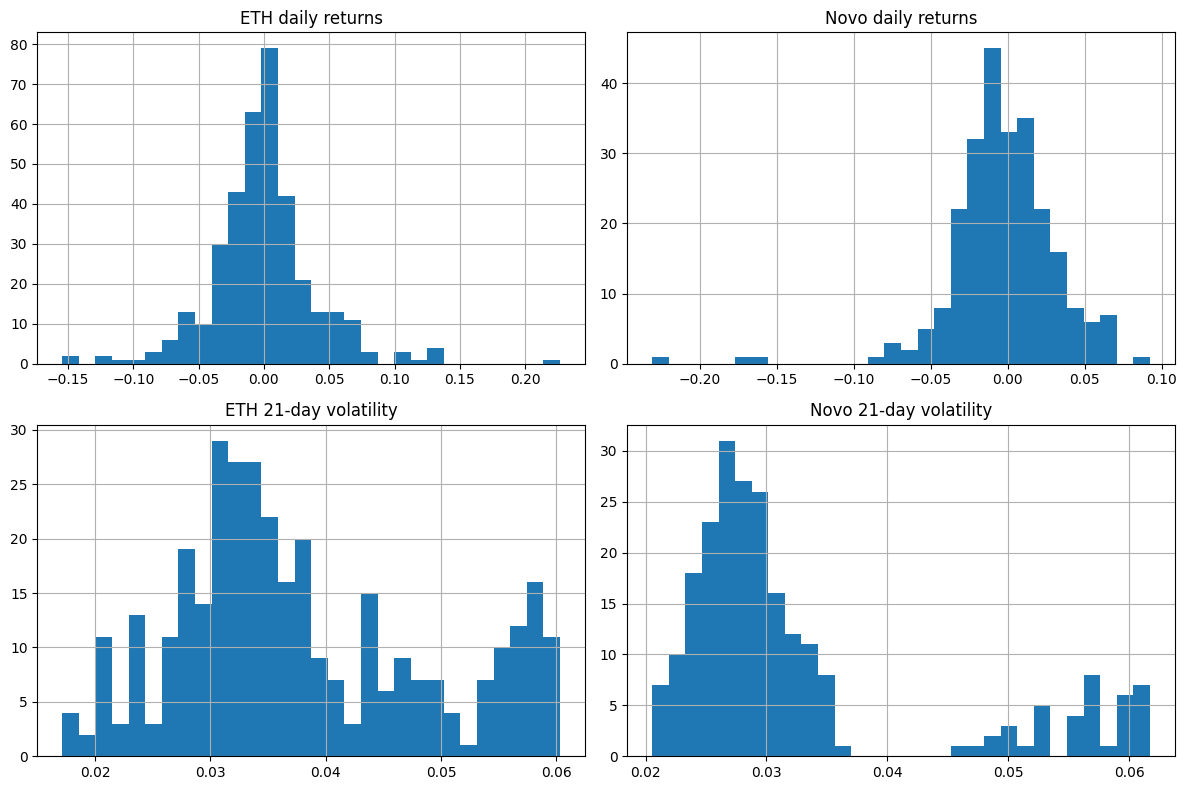

In [5]:

# Histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
eth["ret_1d"].dropna().hist(ax=axes[0, 0], bins=30)
axes[0, 0].set_title("ETH daily returns")

novo["ret_1d"].dropna().hist(ax=axes[0, 1], bins=30)
axes[0, 1].set_title("Novo daily returns")

eth["vol_21"].dropna().hist(ax=axes[1, 0], bins=30)
axes[1, 0].set_title("ETH 21-day volatility")

novo["vol_21"].dropna().hist(ax=axes[1, 1], bins=30)
axes[1, 1].set_title("Novo 21-day volatility")
plt.tight_layout()
plt.show()


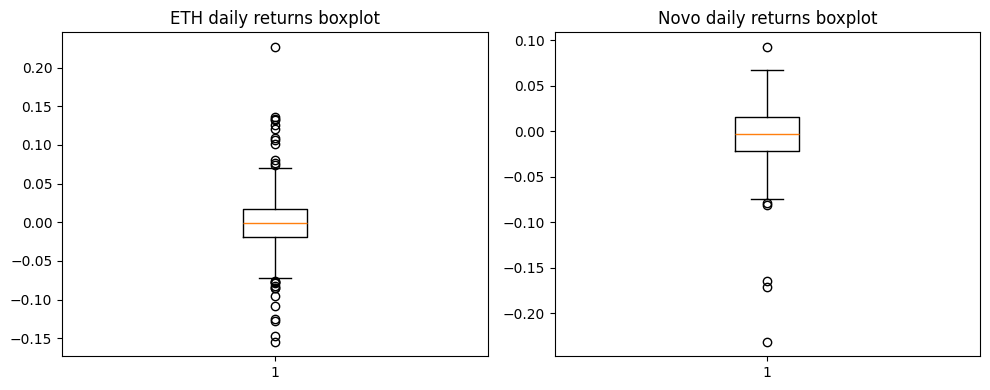

In [6]:

# Boxplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(eth["ret_1d"].dropna())
axes[0].set_title("ETH daily returns boxplot")
axes[1].boxplot(novo["ret_1d"].dropna())
axes[1].set_title("Novo daily returns boxplot")
plt.tight_layout()
plt.show()


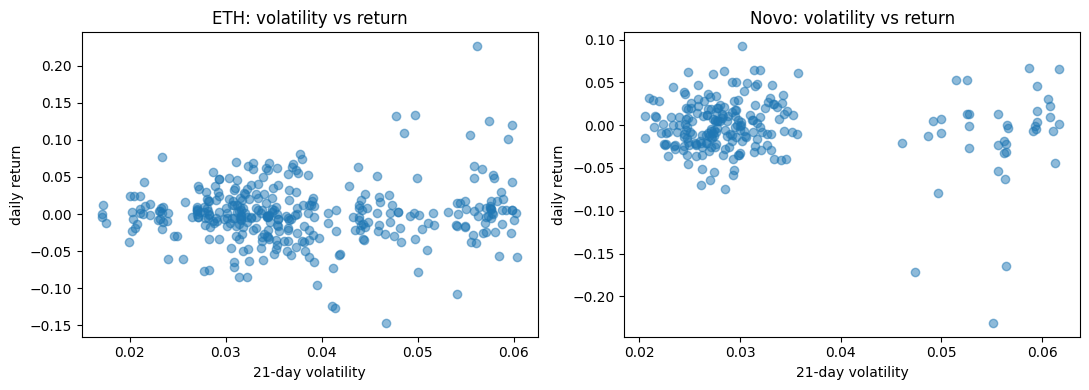

In [7]:

# Key scatter plots
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(eth["vol_21"], eth["ret_1d"], alpha=0.5)
axes[0].set_title("ETH: volatility vs return")
axes[0].set_xlabel("21-day volatility")
axes[0].set_ylabel("daily return")

axes[1].scatter(novo["vol_21"], novo["ret_1d"], alpha=0.5)
axes[1].set_title("Novo: volatility vs return")
axes[1].set_xlabel("21-day volatility")
axes[1].set_ylabel("daily return")
plt.tight_layout()
plt.show()


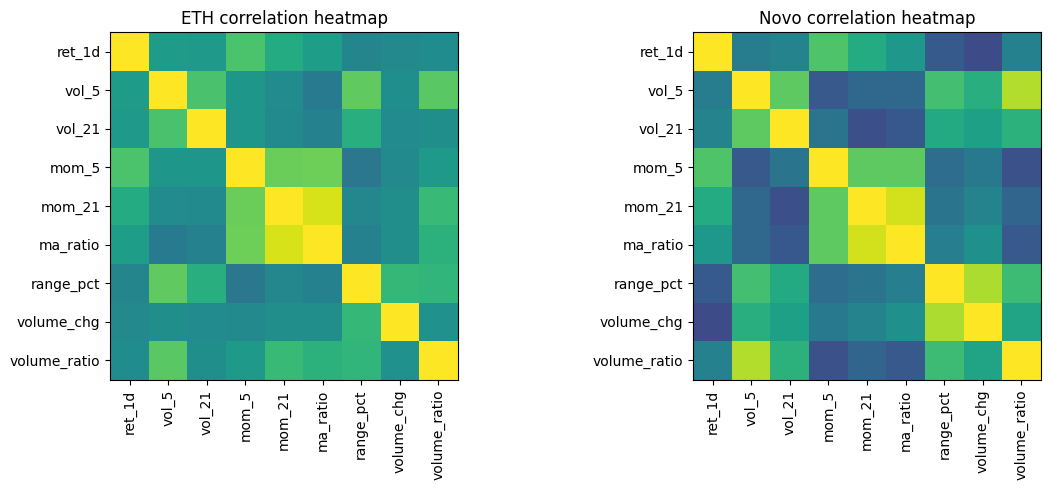

In [8]:

# Correlation heatmaps (numeric subset)
num_cols = ["ret_1d", "vol_5", "vol_21", "mom_5", "mom_21", "ma_ratio", "range_pct", "volume_chg", "volume_ratio"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].imshow(eth[num_cols].corr(), vmin=-1, vmax=1)
axes[0].set_title("ETH correlation heatmap")
axes[0].set_xticks(range(len(num_cols)))
axes[0].set_xticklabels(num_cols, rotation=90)
axes[0].set_yticks(range(len(num_cols)))
axes[0].set_yticklabels(num_cols)

im1 = axes[1].imshow(novo[num_cols].corr(), vmin=-1, vmax=1)
axes[1].set_title("Novo correlation heatmap")
axes[1].set_xticks(range(len(num_cols)))
axes[1].set_xticklabels(num_cols, rotation=90)
axes[1].set_yticks(range(len(num_cols)))
axes[1].set_yticklabels(num_cols)

plt.tight_layout()
plt.show()



### EDA interpretation
The lecture slides recommend checking histograms, skewness, boxplots, key scatter plots, and correlation structure before modelling. The data show:

- **heavy tails and outliers**, especially for Ethereum daily returns,
- **time-varying volatility** in both assets,
- **non-trivial skewness**, which matters for modelling and for anomaly detection,
- correlated momentum/trend variables, which motivates **regularization** in the supervised models.

This supports using:
- probabilistic regime models,
- explicit anomaly detection,
- regularized supervised baselines.


## 4. Descriptive performance and asset selection (RoI first)

In [9]:

def performance_summary(df, periods_per_year):
    r = df["ret_1d"].dropna()
    roi = df["Close"].iloc[-1] / df["Close"].iloc[0] - 1
    ann_return = (1 + roi) ** (periods_per_year / max(len(df) - 1, 1)) - 1
    ann_vol = r.std() * np.sqrt(periods_per_year)
    sharpe_like = r.mean() / r.std() * np.sqrt(periods_per_year) if r.std() != 0 else np.nan
    wealth = df["Close"] / df["Close"].iloc[0]
    max_dd = (wealth / wealth.cummax() - 1).min()
    return pd.Series({
        "Sample ROI": roi,
        "Annualized return": ann_return,
        "Annualized volatility": ann_vol,
        "Sharpe-like": sharpe_like,
        "Max drawdown": max_dd,
        "Positive-day share": (r > 0).mean(),
        "Observations": len(df)
    })

summary = pd.DataFrame({
    "Ethereum": performance_summary(eth, 365),
    "Novo Nordisk": performance_summary(novo, 252)
}).T

display(summary)


,Sample ROI,Annualized return,Annualized volatility,Sharpe-like,Max drawdown,Positive-day share,Observations
Ethereum,-0.2270,-0.2270,0.7808,0.0568,-0.6234,0.4932,366.0000
Novo Nordisk,-0.6293,-0.6337,0.5625,-1.4875,-0.6309,0.4538,250.0000


In [10]:

initial_capital = 250_000

terminal_values = pd.Series({
    "100% Ethereum": initial_capital * (1 + summary.loc["Ethereum", "Sample ROI"]),
    "100% Novo Nordisk": initial_capital * (1 + summary.loc["Novo Nordisk", "Sample ROI"])
}).to_frame("Terminal value (DKK)")

display(terminal_values)


,Terminal value (DKK)
100% Ethereum,"193,258.7598"
100% Novo Nordisk,"92,669.0558"


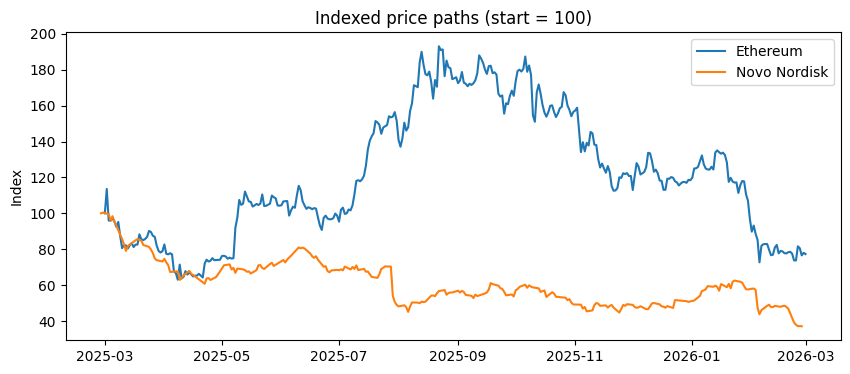

In [11]:

# Indexed price paths
eth_idx = 100 * eth["Close"] / eth["Close"].iloc[0]
novo_idx = 100 * novo["Close"] / novo["Close"].iloc[0]

plt.figure(figsize=(10, 4))
plt.plot(eth["Date"], eth_idx, label="Ethereum")
plt.plot(novo["Date"], novo_idx, label="Novo Nordisk")
plt.title("Indexed price paths (start = 100)")
plt.ylabel("Index")
plt.legend()
plt.show()



### Interpretation for Question 1
Using **RoI as the primary assignment metric**, Ethereum is the better of the two assets over the observed sample.

Why:
- both assets lost money,
- but **Novo Nordisk fell much more**,
- therefore a pure buy-and-hold investor would have preserved more capital in Ethereum than in Novo.

This does **not** mean Ethereum is safe. Its volatility is much higher. But under the assignment's explicit criterion (**RoI first**), Ethereum dominates Novo in this sample.


## 5. Capital allocation strategy

In [12]:

common = (
    eth[["Date", "ret_1d"]]
    .merge(novo[["Date", "ret_1d"]], on="Date", suffixes=("_eth", "_novo"))
    .dropna()
)

grid = np.linspace(0, 1, 21)
alloc_rows = []

for w_eth in grid:
    w_novo = 1 - w_eth
    port_ret = w_eth * common["ret_1d_eth"] + w_novo * common["ret_1d_novo"]
    wealth = (1 + port_ret).cumprod()

    alloc_rows.append({
        "ETH weight": w_eth,
        "Novo weight": w_novo,
        "Portfolio ROI": wealth.iloc[-1] - 1,
        "Annualized volatility": port_ret.std() * np.sqrt(252),
        "Sharpe-like": port_ret.mean() / port_ret.std() * np.sqrt(252) if port_ret.std() != 0 else np.nan,
        "Max drawdown": (wealth / wealth.cummax() - 1).min()
    })

alloc = pd.DataFrame(alloc_rows)
best_roi = alloc.sort_values("Portfolio ROI", ascending=False).head(1)
min_vol = alloc.sort_values("Annualized volatility").head(1)

display(alloc.head())
print("Best ROI allocation")
display(best_roi)

print("Minimum-volatility allocation")
display(min_vol)


,ETH weight,Novo weight,Portfolio ROI,Annualized volatility,Sharpe-like,Max drawdown
0,0.0000,1.0000,-0.6309,0.5636,-1.4982,-0.6278
1,0.0500,0.9500,-0.6108,0.5389,-1.4943,-0.6046
2,0.1000,0.9000,-0.5904,0.5167,-1.4830,-0.5807
3,0.1500,0.8500,-0.5697,0.4973,-1.4623,-0.5563
4,0.2000,0.8000,-0.5490,0.4811,-1.4307,-0.5314


Best ROI allocation


,ETH weight,Novo weight,Portfolio ROI,Annualized volatility,Sharpe-like,Max drawdown
20,1.0000,0.0000,-0.2586,0.6976,-0.0916,-0.6360


Minimum-volatility allocation


,ETH weight,Novo weight,Portfolio ROI,Annualized volatility,Sharpe-like,Max drawdown
8,0.4000,0.6000,-0.4659,0.4530,-1.1747,-0.4728


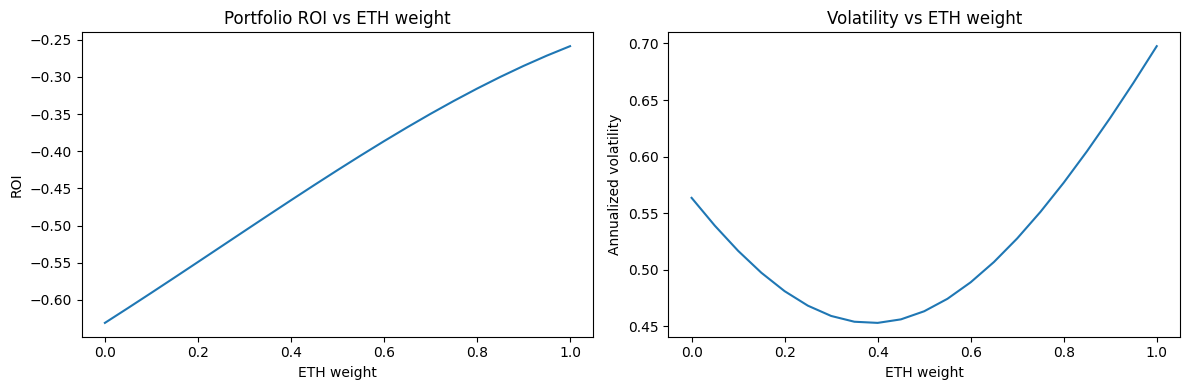

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(alloc["ETH weight"], alloc["Portfolio ROI"])
axes[0].set_title("Portfolio ROI vs ETH weight")
axes[0].set_xlabel("ETH weight")
axes[0].set_ylabel("ROI")

axes[1].plot(alloc["ETH weight"], alloc["Annualized volatility"])
axes[1].set_title("Volatility vs ETH weight")
axes[1].set_xlabel("ETH weight")
axes[1].set_ylabel("Annualized volatility")

plt.tight_layout()
plt.show()



### Interpretation for Question 2
There is a clear trade-off:

- The **highest RoI** in the sample comes from a **pure Ethereum** allocation.
- A **hybrid portfolio** reduces volatility.
- The **lowest-volatility** mix is a more balanced combination, but it also produces a much weaker realized RoI.

So the answer depends on the objective:

- If the assignment is interpreted **strictly by RoI**, the best answer is **100% Ethereum**.
- If a more risk-aware investor wants lower volatility and smaller drawdowns, then a **hybrid mix** is defensible, but it sacrifices return in this specific sample.

For a cautious written answer:
- **RoI-maximizing strategy:** 100% Ethereum
- **Risk-reduction strategy:** a hybrid allocation can reduce volatility, but not improve realized RoI here


## 6. Investment horizon analysis

In [14]:

def horizon_stats(df, horizons):
    rows = []
    for h in horizons:
        fwd = df["Close"].shift(-h) / df["Close"] - 1
        rows.append({
            "Horizon (days)": h,
            "Mean forward ROI": fwd.mean(),
            "Median forward ROI": fwd.median(),
            "Probability positive": (fwd > 0).mean(),
            "Worst case": fwd.min(),
            "Best case": fwd.max()
        })
    return pd.DataFrame(rows)

horizons = [1, 5, 21, 63]
eth_horizon = horizon_stats(eth, horizons)
novo_horizon = horizon_stats(novo, horizons)

print("Ethereum")
display(eth_horizon)

print("Novo Nordisk")
display(novo_horizon)


Ethereum


,Horizon (days),Mean forward ROI,Median forward ROI,Probability positive,Worst case,Best case
0,1,0.0001,-0.0005,0.4918,-0.1544,0.2267
1,5,0.0005,-0.0052,0.4454,-0.2489,0.4269
2,21,0.0130,-0.0298,0.3852,-0.4576,0.6396
3,63,0.1116,0.0742,0.4454,-0.4254,1.1086


Novo Nordisk


,Horizon (days),Mean forward ROI,Median forward ROI,Probability positive,Worst case,Best case
0,1,-0.0033,-0.0029,0.4520,-0.2311,0.0924
1,5,-0.0157,-0.0108,0.4360,-0.3170,0.1550
2,21,-0.0428,-0.0268,0.3840,-0.3948,0.3189
3,63,-0.1116,-0.1296,0.1440,-0.3694,0.1561



### Horizon interpretation
The observed sample suggests:

- **Ethereum** becomes more interesting over longer horizons than over very short horizons; the 63-day average forward RoI is positive, but dispersion is still very large.
- **Novo Nordisk** looks weak across short, medium, and longer horizons in this sample.

That means:
- a **very short-term trading interpretation** is noisy for both assets,
- a **medium/longer holding horizon** is more defensible for Ethereum,
- the dataset gives little support for long-only Novo exposure.


## 7. Seasonality and market timing

In [15]:

def monthly_return_table(df):
    tmp = df.copy()
    tmp["YearMonth"] = tmp["Date"].dt.to_period("M")
    monthly = tmp.groupby("YearMonth").agg(first=("Close", "first"), last=("Close", "last"))
    monthly["monthly_return"] = monthly["last"] / monthly["first"] - 1
    monthly["Month"] = monthly.index.month
    return monthly.groupby("Month")["monthly_return"].agg(["mean", "median", "count"])

eth_month = monthly_return_table(eth)
novo_month = monthly_return_table(novo)

print("Ethereum monthly seasonality")
display(eth_month)

print("Novo monthly seasonality")
display(novo_month)


Ethereum monthly seasonality


,mean,median,count
Month,,,
1,-0.1922,-0.1922,1
2,-0.1315,-0.1315,1
3,-0.1055,-0.1055,2
4,-0.1032,-0.1032,1
5,0.3679,0.3679,1
6,-0.0556,-0.0556,1
7,0.5908,0.5908,1
8,0.2479,0.2479,1
9,-0.0409,-0.0409,1


Novo monthly seasonality


,mean,median,count
Month,,,
1,0.1190,0.1190,1
2,-0.1790,-0.1790,2
3,-0.2649,-0.2649,1
4,-0.0916,-0.0916,1
5,0.0212,0.0212,1
6,-0.0745,-0.0745,1
7,-0.2825,-0.2825,1
8,0.1619,0.1619,1
9,-0.0560,-0.0560,1


In [16]:

eth_dow = eth.groupby("day_name")["ret_1d"].agg(["mean", "median", "count"]).reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)

novo_dow = novo.groupby("day_name")["ret_1d"].agg(["mean", "median", "count"]).reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
)

print("Ethereum day-of-week effects")
display(eth_dow)

print("Novo day-of-week effects")
display(novo_dow)


Ethereum day-of-week effects


,mean,median,count
day_name,,,
Monday,-0.0036,-0.0033,52
Tuesday,0.0030,-0.0014,52
Wednesday,0.0091,0.0020,52
Thursday,-0.0102,-0.0133,52
Friday,-0.0007,0.0007,52
Saturday,0.0023,0.0027,52
Sunday,0.0010,0.0025,53


Novo day-of-week effects


,mean,median,count
day_name,,,
Monday,-0.0016,-0.0021,50
Tuesday,-0.0071,-0.0077,52
Wednesday,-0.0054,-0.0049,50
Thursday,-0.0014,-0.0013,47
Friday,-0.0008,-0.0011,50



### Interpretation for Question 3
There are **some apparent monthly and day-of-week differences**, but they should be treated cautiously.

Reason:
- the sample is roughly **one year**,
- many months have **only one observation in the monthly aggregation**,
- therefore the seasonal estimates are **not statistically stable**.

So the rigorous conclusion is:
- **there is weak descriptive evidence of timing differences**,
- but **not enough history** to claim strong or robust seasonality,
- market timing should rely more on **regime/volatility conditions** than on calendar seasonality alone.


## 8. Market regimes with a probabilistic model (GMM)

In [17]:

def fit_gmm_regimes(df, n_components=2):
    features = df[["ret_1d", "vol_21"]].replace([np.inf, -np.inf], np.nan).dropna().copy()

    scaler = StandardScaler()
    X = scaler.fit_transform(features)

    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(X)

    labels = gmm.predict(X)
    probs = gmm.predict_proba(X)

    stats = (
        features.assign(regime=labels)
        .groupby("regime")
        .agg(
            mean_return=("ret_1d", "mean"),
            return_std=("ret_1d", "std"),
            mean_vol_21=("vol_21", "mean"),
            n=("ret_1d", "size")
        )
    )

    crash_regime = stats["mean_return"].idxmin()

    out = df.copy()
    out["regime"] = np.nan
    out["crash_prob"] = np.nan
    out.loc[features.index, "regime"] = labels
    out.loc[features.index, "crash_prob"] = probs[:, crash_regime]

    return out, stats, crash_regime

eth_reg, eth_reg_stats, eth_crash_regime = fit_gmm_regimes(eth, n_components=2)
novo_reg, novo_reg_stats, novo_crash_regime = fit_gmm_regimes(novo, n_components=2)

print("Ethereum regime statistics")
display(eth_reg_stats)

print("Novo Nordisk regime statistics")
display(novo_reg_stats)


Ethereum regime statistics


,mean_return,return_std,mean_vol_21,n
regime,,,,
0,-0.0011,0.0319,0.0323,254
1,0.0048,0.0561,0.0534,91


Novo Nordisk regime statistics


,mean_return,return_std,mean_vol_21,n
regime,,,,
0,-0.0155,0.0606,0.0557,39
1,0.0003,0.0279,0.0279,190


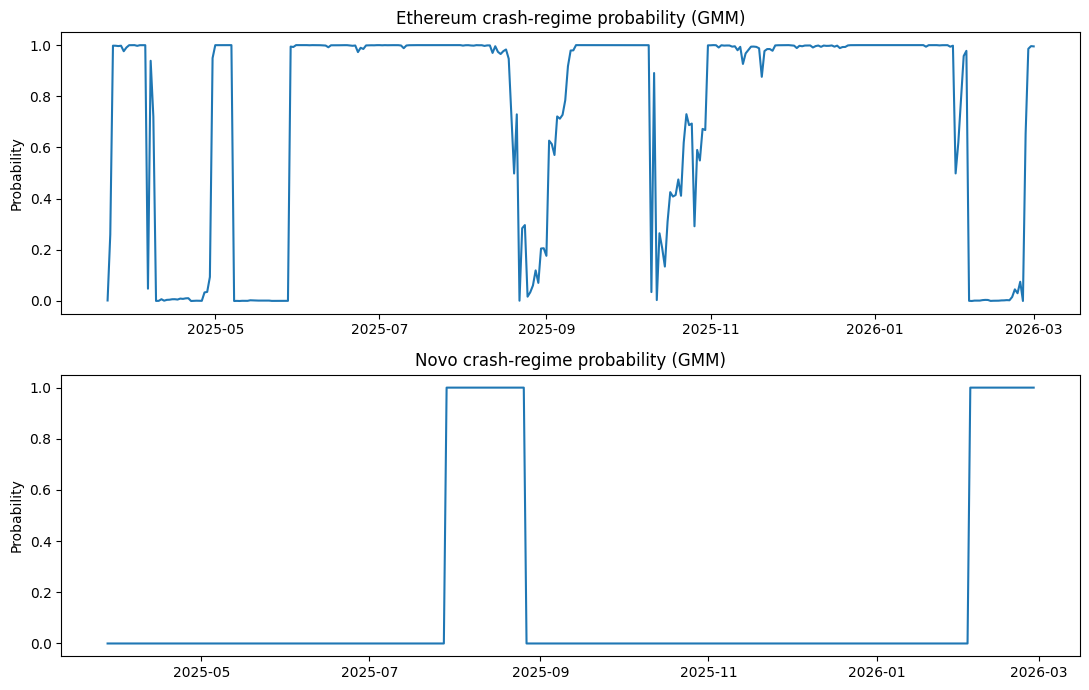

In [18]:

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=False)

axes[0].plot(eth_reg["Date"], eth_reg["crash_prob"])
axes[0].set_title("Ethereum crash-regime probability (GMM)")
axes[0].set_ylabel("Probability")

axes[1].plot(novo_reg["Date"], novo_reg["crash_prob"])
axes[1].set_title("Novo crash-regime probability (GMM)")
axes[1].set_ylabel("Probability")

plt.tight_layout()
plt.show()



### Why GMM is appropriate here
The assignment explicitly asks for the probability that each asset is in a crash regime.  
A **Gaussian Mixture Model** is course-aligned and appropriate because:

- it is an **unsupervised** method from the lectures,
- it provides **probabilistic cluster membership**,
- therefore it can translate naturally into a **crash-regime probability**.

### Interpretation
- For **Ethereum**, the lower-return regime still coexists with very high volatility, and crash risk varies substantially across time.
- For **Novo**, the crash-like regime is associated with more clearly negative average returns and elevated volatility.

This strengthens the earlier descriptive finding: both assets are risky, but Novo spent more of the sample in an unfavorable state.


## 9. Extreme-event detection with Isolation Forest

In [19]:

def detect_anomalies(df, contamination=0.03):
    feats = df[["ret_1d", "range_pct", "vol_21"]].replace([np.inf, -np.inf], np.nan).dropna()
    X = StandardScaler().fit_transform(feats)

    iso = IsolationForest(contamination=contamination, random_state=42)
    flags = iso.fit_predict(X)
    scores = -iso.score_samples(X)

    out = df.copy()
    out["anomaly"] = False
    out["anomaly_score"] = np.nan
    out.loc[feats.index, "anomaly"] = (flags == -1)
    out.loc[feats.index, "anomaly_score"] = scores
    return out

eth_reg = detect_anomalies(eth_reg)
novo_reg = detect_anomalies(novo_reg)

print("Largest ETH anomalies")
display(
    eth_reg.loc[eth_reg["anomaly"], ["Date", "Close", "ret_1d", "range_pct", "crash_prob", "anomaly_score"]]
    .sort_values("anomaly_score", ascending=False)
    .head(10)
)

print("Largest Novo anomalies")
display(
    novo_reg.loc[novo_reg["anomaly"], ["Date", "Close", "ret_1d", "range_pct", "crash_prob", "anomaly_score"]]
    .sort_values("anomaly_score", ascending=False)
    .head(10)
)


Largest ETH anomalies


,Date,Close,ret_1d,range_pct,crash_prob,anomaly_score
68,2025-05-08,"14,662.5900",0.2267,0.1890,0.0000,0.7384
223,2025-10-10,"24,627.7800",-0.1271,0.2503,0.0348,0.7295
341,2026-02-05,"11,586.2100",-0.1471,0.1900,0.0006,0.7076
39,2025-04-09,"11,381.3800",0.1335,0.1821,0.0003,0.6788
40,2025-04-10,"10,148.2300",-0.1083,0.1306,0.0006,0.6603
248,2025-11-04,"21,374.3700",-0.0848,0.1810,0.9907,0.6496
36,2025-04-06,"10,761.3400",-0.1247,0.1768,0.0481,0.6462
342,2026-02-06,"13,044.6500",0.1259,0.1515,0.0000,0.6407
52,2025-04-22,"11,474.7000",0.1207,0.1371,0.0000,0.6384
174,2025-08-22,"30,768.2100",0.1322,0.1408,0.0011,0.6327


Largest Novo anomalies


,Date,Close,ret_1d,range_pct,crash_prob,anomaly_score
101,2025-07-29,346.9000,-0.2311,0.3847,1.0000,0.8143
245,2026-02-23,251.4000,-0.1648,0.1973,1.0000,0.7290
232,2026-02-04,304.6500,-0.1717,0.0607,1.0000,0.6910
108,2025-08-07,308.8500,0.0668,0.1405,1.0000,0.6859
233,2026-02-05,280.6500,-0.0788,0.1094,1.0000,0.6638
185,2025-11-24,287.0000,-0.0579,0.1538,0.0000,0.6605
30,2025-04-10,409.5500,0.0139,0.1354,0.0000,0.6059



### Interpretation
This step implements the assignment hint about **anomaly detection**.

The anomalies correspond to days with combinations of:
- unusually large returns,
- unusually wide trading ranges,
- elevated recent volatility.

That is useful because a naive RoI comparison can hide how much path risk the investor would have experienced.  
Ethereum is the stronger RoI asset in the sample, but it also shows more dramatic extreme-event behavior.


## 10. Supervised baseline models


The lecture slides emphasize:
- training/validation/test separation,
- regularization,
- cross-validation,
- interpretable models.

So the supervised section uses:
1. **Elastic-net logistic regression** to predict **future return direction**,
2. **Elastic Net regression** to predict future return magnitude,
3. a **shallow decision tree** to extract transparent decision rules.

Because the data are ordered in time, the tuning uses **TimeSeriesSplit** instead of random folds.


In [20]:

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def supervised_models(df, horizon=5):
    data = df.copy()
    data["target_return"] = data["Close"].shift(-horizon) / data["Close"] - 1
    data["target_dir"] = (data["target_return"] > 0).astype(int)

    feat_cols = [
        "ret_1d", "vol_5", "vol_21", "mom_5", "mom_21",
        "ma_ratio", "range_pct", "volume_chg", "volume_ratio", "crash_prob"
    ]

    dataset = data[feat_cols + ["target_return", "target_dir", "Date"]].dropna().reset_index(drop=True)

    n = len(dataset)
    train_end = int(n * 0.70)
    val_end = int(n * 0.85)

    train = dataset.iloc[:train_end]
    val = dataset.iloc[train_end:val_end]
    test = dataset.iloc[val_end:]

    X_train = train[feat_cols]
    y_train = train["target_dir"]
    X_val = val[feat_cols]
    y_val = val["target_dir"]
    X_test = test[feat_cols]
    y_test = test["target_dir"]

    # Elastic-net logistic regression
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(solver="saga", penalty="elasticnet", max_iter=5000))
    ])

    param_grid = {
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__l1_ratio": [0.0, 0.5, 1.0]
    }

    cv = TimeSeriesSplit(n_splits=5)
    grid = GridSearchCV(pipe, param_grid, cv=cv, scoring="roc_auc")
    grid.fit(X_train, y_train)
    best_params = grid.best_params_

    best_val_model = grid.best_estimator_

    def clf_metrics(model, X, y):
        pred = model.predict(X)
        prob = model.predict_proba(X)[:, 1]
        return pd.Series({
            "Accuracy": accuracy_score(y, pred),
            "Precision": precision_score(y, pred, zero_division=0),
            "Recall": recall_score(y, pred, zero_division=0),
            "F1": f1_score(y, pred, zero_division=0),
            "ROC_AUC": roc_auc_score(y, prob) if len(np.unique(y)) > 1 else np.nan
        })

    val_metrics = clf_metrics(best_val_model, X_val, y_val)

    # Refit with train + validation, evaluate only once on test
    X_trainval = dataset.iloc[:val_end][feat_cols]
    y_trainval = dataset.iloc[:val_end]["target_dir"]

    final_clf = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="saga",
            penalty="elasticnet",
            max_iter=5000,
            C=best_params["clf__C"],
            l1_ratio=best_params["clf__l1_ratio"]
        ))
    ])
    final_clf.fit(X_trainval, y_trainval)
    test_metrics = clf_metrics(final_clf, X_test, y_test)

    clf_coefs = pd.Series(
        final_clf.named_steps["clf"].coef_[0],
        index=feat_cols
    ).sort_values(key=np.abs, ascending=False)

    # Elastic Net regression baseline
    reg_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("reg", ElasticNet(max_iter=10000, random_state=42))
    ])

    reg_grid = GridSearchCV(
        reg_pipe,
        {"reg__alpha": [0.001, 0.01, 0.1, 1.0], "reg__l1_ratio": [0.0, 0.5, 1.0]},
        cv=cv,
        scoring="neg_mean_squared_error"
    )
    reg_grid.fit(X_train, train["target_return"])
    reg_best_params = reg_grid.best_params_

    final_reg = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("reg", ElasticNet(
            max_iter=10000,
            random_state=42,
            alpha=reg_best_params["reg__alpha"],
            l1_ratio=reg_best_params["reg__l1_ratio"]
        ))
    ])
    final_reg.fit(X_trainval, dataset.iloc[:val_end]["target_return"])
    pred_ret = final_reg.predict(X_test)

    reg_metrics = pd.Series({
        "MAE": mean_absolute_error(test["target_return"], pred_ret),
        "RMSE": rmse(test["target_return"], pred_ret),
        "R2": r2_score(test["target_return"], pred_ret)
    })

    reg_coefs = pd.Series(
        final_reg.named_steps["reg"].coef_,
        index=feat_cols
    ).sort_values(key=np.abs, ascending=False)

    # Interpretable decision tree
    tree = DecisionTreeClassifier(
        max_depth=3,
        min_samples_leaf=max(10, int(len(X_trainval) * 0.05)),
        random_state=42
    )
    tree.fit(X_trainval, y_trainval)
    tree_pred = tree.predict(X_test)
    tree_prob = tree.predict_proba(X_test)[:, 1]

    tree_metrics = pd.Series({
        "Accuracy": accuracy_score(y_test, tree_pred),
        "Precision": precision_score(y_test, tree_pred, zero_division=0),
        "Recall": recall_score(y_test, tree_pred, zero_division=0),
        "F1": f1_score(y_test, tree_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, tree_prob) if len(np.unique(y_test)) > 1 else np.nan
    })

    rules = export_text(tree, feature_names=feat_cols)

    return {
        "n_total": len(dataset),
        "n_train": len(train),
        "n_val": len(val),
        "n_test": len(test),
        "best_clf_params": best_params,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "clf_coefs": clf_coefs,
        "best_reg_params": reg_best_params,
        "reg_metrics": reg_metrics,
        "reg_coefs": reg_coefs,
        "tree_metrics": tree_metrics,
        "rules": rules
    }

def run_horizon_search(df, horizons=(1, 5, 21)):
    results = {h: supervised_models(df, horizon=h) for h in horizons}
    val_table = pd.DataFrame({h: r["val_metrics"] for h, r in results.items()}).T
    test_table = pd.DataFrame({h: r["test_metrics"] for h, r in results.items()}).T
    return results, val_table, test_table

eth_models, eth_val, eth_test = run_horizon_search(eth_reg, horizons=(1, 5, 21))
novo_models, novo_val, novo_test = run_horizon_search(novo_reg, horizons=(1, 5, 21))

print("Ethereum validation metrics by horizon")
display(eth_val)

print("Ethereum test metrics by horizon")
display(eth_test)

print("Novo validation metrics by horizon")
display(novo_val)

print("Novo test metrics by horizon")
display(novo_test)


Ethereum validation metrics by horizon


,Accuracy,Precision,Recall,F1,ROC_AUC
1,0.4615,0.4737,0.6923,0.5625,0.4956
5,0.4615,0.0000,0.0000,0.0000,0.5000
21,0.5510,0.4000,0.4444,0.4211,0.5054


Ethereum test metrics by horizon


,Accuracy,Precision,Recall,F1,ROC_AUC
1,0.3462,0.3158,0.6000,0.4138,0.3984
5,0.7059,0.0000,0.0000,0.0000,0.5000
21,0.6735,0.2000,0.2000,0.2000,0.4333


Novo validation metrics by horizon


,Accuracy,Precision,Recall,F1,ROC_AUC
1,0.4412,0.0000,0.0000,0.0000,0.5018
5,0.4412,0.0000,0.0000,0.0000,0.2491
21,0.3871,0.5000,0.0526,0.0952,0.5482


Novo test metrics by horizon


,Accuracy,Precision,Recall,F1,ROC_AUC
1,0.5429,0.3636,0.3077,0.3333,0.4895
5,0.5000,0.3846,0.3571,0.3704,0.3893
21,0.5625,0.0000,0.0000,0.0000,0.8254


In [21]:

# Select the horizon with the best validation ROC-AUC for each asset
eth_best_h = eth_val["ROC_AUC"].idxmax()
novo_best_h = novo_val["ROC_AUC"].idxmax()

print("Best Ethereum horizon:", eth_best_h, "trading day(s)")
print("Best Novo horizon:", novo_best_h, "trading day(s)")

eth_best = eth_models[eth_best_h]
novo_best = novo_models[novo_best_h]

print("\nETH chosen logistic-regression coefficients")
display(eth_best["clf_coefs"].to_frame("coefficient"))

print("\nNovo chosen logistic-regression coefficients")
display(novo_best["clf_coefs"].to_frame("coefficient"))

print("\nETH chosen regression coefficients")
display(eth_best["reg_coefs"].to_frame("coefficient"))

print("\nNovo chosen regression coefficients")
display(novo_best["reg_coefs"].to_frame("coefficient"))


Best Ethereum horizon: 21 trading day(s)
Best Novo horizon: 21 trading day(s)

ETH chosen logistic-regression coefficients


,coefficient
volume_chg,0.1170
mom_21,0.1151
range_pct,0.0758
volume_ratio,0.0372
vol_5,-0.0175
crash_prob,-0.0143
ret_1d,-0.0125
ma_ratio,0.0000
vol_21,0.0000
mom_5,0.0000



Novo chosen logistic-regression coefficients


,coefficient
vol_21,0.2367
crash_prob,0.1405
range_pct,0.1230
mom_21,-0.1135
vol_5,0.0777
ma_ratio,-0.0683
volume_ratio,0.0633
ret_1d,-0.0204
mom_5,-0.0184
volume_chg,0.0002



ETH chosen regression coefficients


,coefficient
ret_1d,0.0000
vol_5,0.0000
vol_21,0.0000
mom_5,0.0000
mom_21,0.0000
ma_ratio,0.0000
range_pct,0.0000
volume_chg,0.0000
volume_ratio,0.0000
crash_prob,0.0000



Novo chosen regression coefficients


,coefficient
ret_1d,0.0000
vol_5,0.0000
vol_21,0.0000
mom_5,0.0000
mom_21,0.0000
ma_ratio,0.0000
range_pct,0.0000
volume_chg,0.0000
volume_ratio,0.0000
crash_prob,0.0000


In [22]:

print("Ethereum decision-tree rules")
print(eth_best["rules"])

print("\nNovo decision-tree rules")
print(novo_best["rules"])


Ethereum decision-tree rules
|--- mom_21 <= 0.07
|   |--- crash_prob <= 0.09
|   |   |--- class: 1
|   |--- crash_prob >  0.09
|   |   |--- range_pct <= 0.08
|   |   |   |--- class: 0
|   |   |--- range_pct >  0.08
|   |   |   |--- class: 1
|--- mom_21 >  0.07
|   |--- vol_21 <= 0.04
|   |   |--- vol_21 <= 0.03
|   |   |   |--- class: 1
|   |   |--- vol_21 >  0.03
|   |   |   |--- class: 1
|   |--- vol_21 >  0.04
|   |   |--- volume_ratio <= 0.10
|   |   |   |--- class: 1
|   |   |--- volume_ratio >  0.10
|   |   |   |--- class: 0


Novo decision-tree rules
|--- vol_21 <= 0.03
|   |--- mom_21 <= -0.19
|   |   |--- class: 1
|   |--- mom_21 >  -0.19
|   |   |--- vol_21 <= 0.03
|   |   |   |--- class: 0
|   |   |--- vol_21 >  0.03
|   |   |   |--- class: 1
|--- vol_21 >  0.03
|   |--- vol_21 <= 0.03
|   |   |--- class: 1
|   |--- vol_21 >  0.03
|   |   |--- class: 1




### Supervised-model interpretation
This section is intentionally conservative.

Findings:
- Predictive performance is **weak overall**, which is realistic for financial return prediction on a small sample.
- For **Ethereum**, the regularized logistic model shrinks most coefficients strongly, suggesting **limited stable predictive structure**.
- For **Novo**, some signal appears in the ranking/probability output at longer horizons, but threshold-based classification remains unstable.

That is actually a valuable result:
- the course emphasizes guarding against overfitting,
- the regularized models are telling us **not to overclaim predictability**.

The decision tree still provides transparent rule patterns, but these should be interpreted as **descriptive investment rules** rather than guaranteed trading edges.


## 11. Final answers to the assignment questions

In [23]:

final_answers = pd.DataFrame({
    "Question": [
        "1. Asset selection",
        "2. Capital allocation",
        "3. Market timing / seasonality"
    ],
    "Answer": [
        "Ethereum is preferred over Novo Nordisk on the assignment's primary metric (RoI), because it lost much less over the sample.",
        "If RoI is the objective, the sample supports a pure Ethereum allocation. A hybrid allocation reduces volatility, but not realized RoI in this dataset.",
        "Calendar-based seasonality is weak because the sample is short. Timing should rely more on volatility/regime conditions than on month-of-year effects."
    ]
})

display(final_answers)


,Question,Answer
0,1. Asset selection,Ethereum is preferred over Novo Nordisk on the...
1,2. Capital allocation,"If RoI is the objective, the sample supports a..."
2,3. Market timing / seasonality,Calendar-based seasonality is weak because the...



## Final written conclusion
A rigorous, course-aligned reading of the data leads to the following answer:

1. **Asset Selection:**  
   Based on **RoI**, Ethereum is preferred to Novo Nordisk over the observed sample. Both performed poorly in absolute terms, but Novo performed substantially worse.

2. **Capital Allocation Strategy:**  
   The **RoI-maximizing** allocation is **100% Ethereum**.  
   A **hybrid allocation** is reasonable only if the investor explicitly wants to reduce volatility and drawdowns, knowing that this gives up return in this sample.

3. **Market Timing and Seasonality:**  
   There is **limited descriptive evidence** of timing differences by month or day, but the sample is too short for strong seasonal claims.  
   More informative timing signals come from:
   - **regime probabilities** from the GMM,
   - **volatility conditions**,
   - and **anomaly detection** for extreme days.

4. **Supervised prediction:**  
   Regularized and interpretable supervised baselines do **not** reveal strong, stable predictive power. This is important because it shows methodological discipline and avoids overfitting.

### Bottom line
If forced to decide using the assignment's primary metric (**RoI**), the best-supported answer is:

> **Choose Ethereum over Novo Nordisk, and use a pure Ethereum allocation if maximizing realized RoI is the goal.**  
> **Use a hybrid allocation only as a risk-control choice, not as a return-maximizing one.**
